In [15]:
# 每次 attempt 的 score + token 使用，以及单次 vs 多次 attempt 的对比
import json
from pathlib import Path

import pandas as pd

# 结果文件路径（与上方保持一致，如果你改了路径，这里也要一起改）
RESULTS_PATH = "/root/skill/results/0021_minimax-cn-MiniMax-M2-5.json"

with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    _data = json.load(f)

_tasks = _data.get("tasks", [])
_efficiency = _data.get("efficiency", {}) or {}
_per_task_eff = {x["task_id"]: x for x in (_efficiency.get("per_task") or [])}

# 1) 每次 attempt 的明细：score + tokens
attempt_rows = []

for t in _tasks:
    task_id = t.get("task_id", "")
    name = (t.get("frontmatter") or {}).get("name") or task_id
    attempts = t.get("attempts") or []

    for a in attempts:
        g = a.get("grading") or {}
        ex = a.get("execution") or {}
        u = (ex.get("usage") or {}) or (a.get("usage") or {})

        attempt_rows.append({
            "task_id": task_id,
            "name": name,
            "attempt": int(a.get("attempt", 0)),
            "score": float(g.get("score", 0)),
            "max_score": float(g.get("max_score", 1) or 1),
            "execution_time": float(ex.get("execution_time", 0)),
            "status": ex.get("status", ""),
            "input_tokens": float(u.get("input_tokens") or 0),
            "output_tokens": float(u.get("output_tokens") or 0),
            "total_tokens": float(u.get("total_tokens") or 0),
        })

if attempt_rows:
    df_attempts = pd.DataFrame(attempt_rows)
    df_attempts["score_pct"] = (df_attempts["score"] / df_attempts["max_score"].replace(0, 1) * 100).round(1)
    display(df_attempts[[
        "task_id", "attempt", "score", "max_score", "score_pct",
        "execution_time", "status",
        "input_tokens", "output_tokens", "total_tokens",
    ]])
else:
    print("没有 attempt 明细数据。")

# 2) 对比：仅第一次 attempt vs 允许多次 attempt 后的最终结果

# 每个任务取「仅第一次 attempt」的 score + token（区分 input/output）
first_attempt_scores = []
first_input_tokens = []
first_output_tokens = []
first_total_tokens_incl_cache = []

# 每个任务取「允许多次 attempt 后的最终」score 和「全部 attempt 累计」token
final_scores = []
all_input_tokens = []
all_output_tokens = []
all_total_tokens_incl_cache = []

for t in _tasks:
    attempts = t.get("attempts") or []
    comp = t.get("completion") or {}

    # 最终得分（多次 attempt 下的结果）
    final_scores.append(float(comp.get("score", 0)))

    task_input_sum = 0.0
    task_output_sum = 0.0
    task_total_sum = 0.0
    first_score = None
    first_in = None
    first_out = None
    first_total = None

    for a in attempts:
        ex = a.get("execution") or {}
        u = (ex.get("usage") or {}) or (a.get("usage") or {})

        in_tok = float(u.get("input_tokens", u.get("input", 0)) or 0)
        out_tok = float(u.get("output_tokens", u.get("output", 0)) or 0)
        total_tok = float(u.get("total_tokens", u.get("totalTokens", 0)) or 0)

        task_input_sum += in_tok
        task_output_sum += out_tok
        task_total_sum += total_tok

        if first_total is None:
            first_in = in_tok
            first_out = out_tok
            first_total = total_tok
            g = a.get("grading") or {}
            first_score = float(g.get("score", 0))

    all_input_tokens.append(task_input_sum)
    all_output_tokens.append(task_output_sum)
    all_total_tokens_incl_cache.append(task_total_sum)

    first_attempt_scores.append(first_score if first_score is not None else 0.0)
    first_input_tokens.append(first_in if first_in is not None else 0.0)
    first_output_tokens.append(first_out if first_out is not None else 0.0)
    first_total_tokens_incl_cache.append(first_total if first_total is not None else 0.0)

n_tasks = len(_tasks)

# 汇总表：两行对比（显式区分 input/output 以及 total 是否含 cache）
summary = [
    {
        "场景": "仅第一次 attempt（不允许多次重试）",
        "任务数": n_tasks,
        "所有任务平均 score": sum(first_attempt_scores) / n_tasks if n_tasks else 0,
        "输入 token 总和（不含 cache）": sum(first_input_tokens),
        "输出 token 总和（不含 cache）": sum(first_output_tokens),
        "total_tokens 总和（一般含 cache）": sum(first_total_tokens_incl_cache),
    },
    {
        "场景": "允许多次 attempt（取最终得分，统计全部 attempt 的 token）",
        "任务数": n_tasks,
        "所有任务平均 score": sum(final_scores) / n_tasks if n_tasks else 0,
        "输入 token 总和（不含 cache）": sum(all_input_tokens),
        "输出 token 总和（不含 cache）": sum(all_output_tokens),
        "total_tokens 总和（一般含 cache）": sum(all_total_tokens_incl_cache),
    },
]

summary_df = pd.DataFrame(summary)
print("引入多次 attempt 前后对比（同一批任务，区分 input/output）：")
display(summary_df)


,task_id,attempt,score,max_score,score_pct,execution_time,status,input_tokens,output_tokens,total_tokens
0,task_00_sanity,1,1.000000,1.0,100.0,11.127899,success,20.0,33.0,10465.0
1,task_01_calendar,1,1.000000,1.0,100.0,27.929595,success,1078.0,627.0,32967.0
2,task_02_stock,1,0.000000,1.0,0.0,180.120532,timeout,370103.0,2980.0,580998.0
3,task_02_stock,2,1.000000,1.0,100.0,42.871202,error,779173.0,4544.0,1132050.0
4,task_03_blog,1,0.960000,1.0,96.0,35.407719,success,813.0,910.0,22540.0
5,task_03_blog,2,0.960000,1.0,96.0,27.685718,success,10025.0,1788.0,85709.0
6,task_04_weather,1,1.000000,1.0,100.0,132.859651,success,53539.0,3591.0,285829.0
7,task_05_summary,1,1.000000,1.0,100.0,22.803130,success,1912.0,452.0,33572.0
8,task_06_events,1,0.780000,1.0,78.0,75.267828,success,36768.0,1096.0,121043.0
9,task_06_events,2,0.830000,1.0,83.0,59.375907,success,58304.0,2138.0,191914.0


引入多次 attempt 前后对比（同一批任务，区分 input/output）：


,场景,任务数,所有任务平均 score,输入 token 总和（不含 cache）,输出 token 总和（不含 cache）,total_tokens 总和（一般含 cache）
0,仅第一次 attempt（不允许多次重试）,23,0.789726,1439953.0,31524.0,2959656.0
1,允许多次 attempt（取最终得分，统计全部 attempt 的 token）,23,0.927791,9541385.0,210984.0,18117911.0


# PinchBench 结果可视化

读取 `results/*.json`，按 **task**、**模型**（单文件时为当前 run）展示：
- 各任务得分与耗时
- 各任务 attempt 次数
- 每个 task 按 **attempts** 解析：每一轮的得分与耗时

In [2]:
# 依赖（如无则 pip install matplotlib pandas）
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans", "SimHei", "Arial Unicode MS"]
matplotlib.rcParams["axes.unicode_minus"] = False

RESULTS_PATH = "/root/skill/results/0021_minimax-cn-MiniMax-M2-5.json"
with open(RESULTS_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)

model = data.get("model", "unknown")
run_id = data.get("run_id", "")
tasks = data.get("tasks", [])
efficiency = data.get("efficiency", {})

print(f"Model: {model}  Run: {run_id}   Tasks: {len(tasks)}")

Model: minimax-cn/MiniMax-M2.5  Run: 0021   Tasks: 23


In [3]:
# 解析：按 task 汇总 + 按 attempts 拆开每一轮
def parse_task(t):
    name = (t.get("frontmatter") or {}).get("name") or t.get("task_id", "")
    comp = t.get("completion") or {}
    score = float(comp.get("score", 0))
    max_score = float(comp.get("max_score", 1) or 1)
    attempt_count = int(t.get("attempt_count", 1))
    execution_time = float(t.get("execution_time", 0))
    attempts_detail = []
    for a in t.get("attempts") or []:
        g = a.get("grading") or {}
        ex = a.get("execution") or {}
        attempts_detail.append({
            "attempt": int(a.get("attempt", 0)),
            "score": float(g.get("score", 0)),
            "max_score": float(g.get("max_score", 1) or 1),
            "execution_time": float(ex.get("execution_time", 0)),
            "status": ex.get("status", ""),
        })
    return {
        "task_id": t.get("task_id", ""),
        "name": name,
        "score": score,
        "max_score": max_score,
        "execution_time": execution_time,
        "attempt_count": attempt_count,
        "attempts": attempts_detail,
    }

rows = [parse_task(t) for t in tasks]
task_ids = [r["task_id"] for r in rows]
scores = [r["score"] for r in rows]
max_scores = [r["max_score"] for r in rows]
times = [r["execution_time"] for r in rows]
attempt_counts = [r["attempt_count"] for r in rows]
print("Parsed", len(rows), "tasks. Sample:", rows[0]["task_id"], "score", rows[0]["score"], "attempts", rows[0]["attempt_count"])

Parsed 23 tasks. Sample: task_00_sanity score 1.0 attempts 1


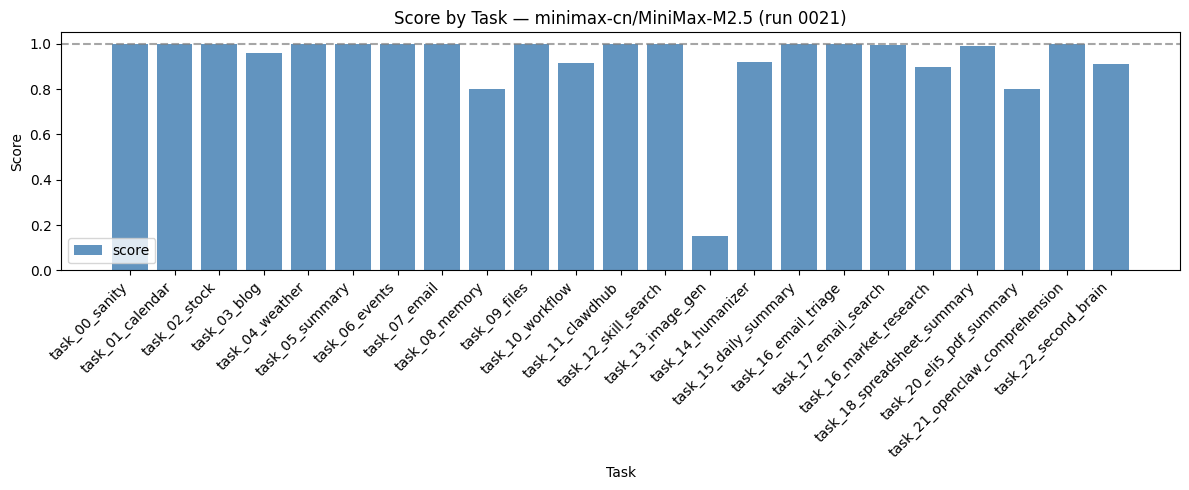

0.9277913043478262


In [10]:
# 图1：各任务得分（按 task）
fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(task_ids))
bars = ax.bar(x, scores, color="steelblue", alpha=0.85, label="score")
ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(task_ids, rotation=45, ha="right")
ax.set_ylabel("Score")
ax.set_xlabel("Task")
ax.set_title(f"Score by Task — {model} (run {run_id})")
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()
print(sum(scores)/len(scores))

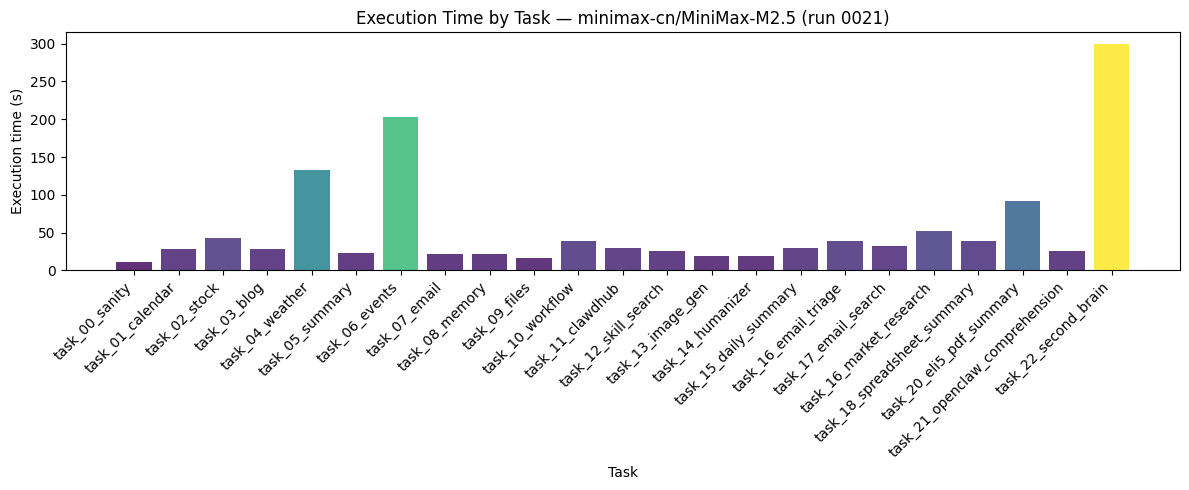

In [5]:
# 图2：各任务耗时（秒）
fig, ax = plt.subplots(figsize=(12, 5))
colors = plt.cm.viridis([t / max(times) if max(times) > 0 else 0 for t in times])
ax.bar(x, times, color=colors, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_ids, rotation=45, ha="right")
ax.set_ylabel("Execution time (s)")
ax.set_xlabel("Task")
ax.set_title(f"Execution Time by Task — {model} (run {run_id})")
plt.tight_layout()
plt.show()

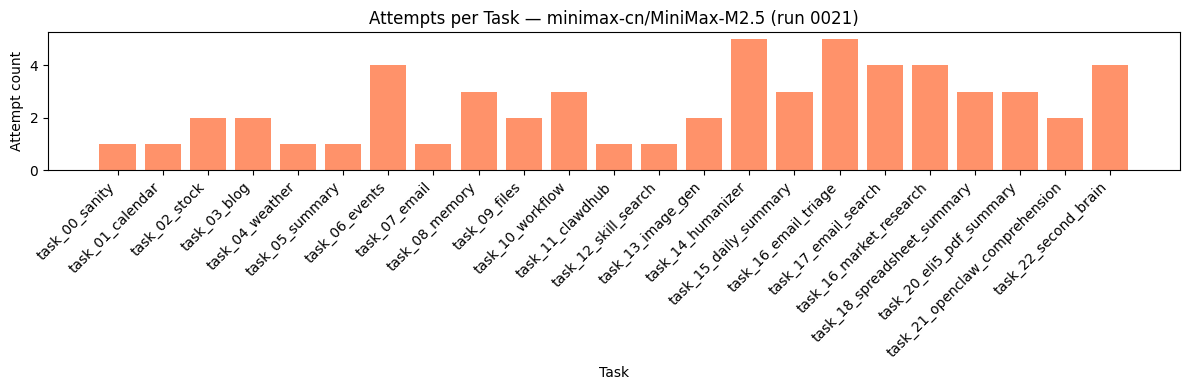

In [6]:
# 图3：各任务 attempt 次数
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x, attempt_counts, color="coral", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(task_ids, rotation=45, ha="right")
ax.set_ylabel("Attempt count")
ax.set_xlabel("Task")
ax.set_title(f"Attempts per Task — {model} (run {run_id})")
plt.tight_layout()
plt.show()

## 按 attempts 解析：每个 task 各轮得分与耗时

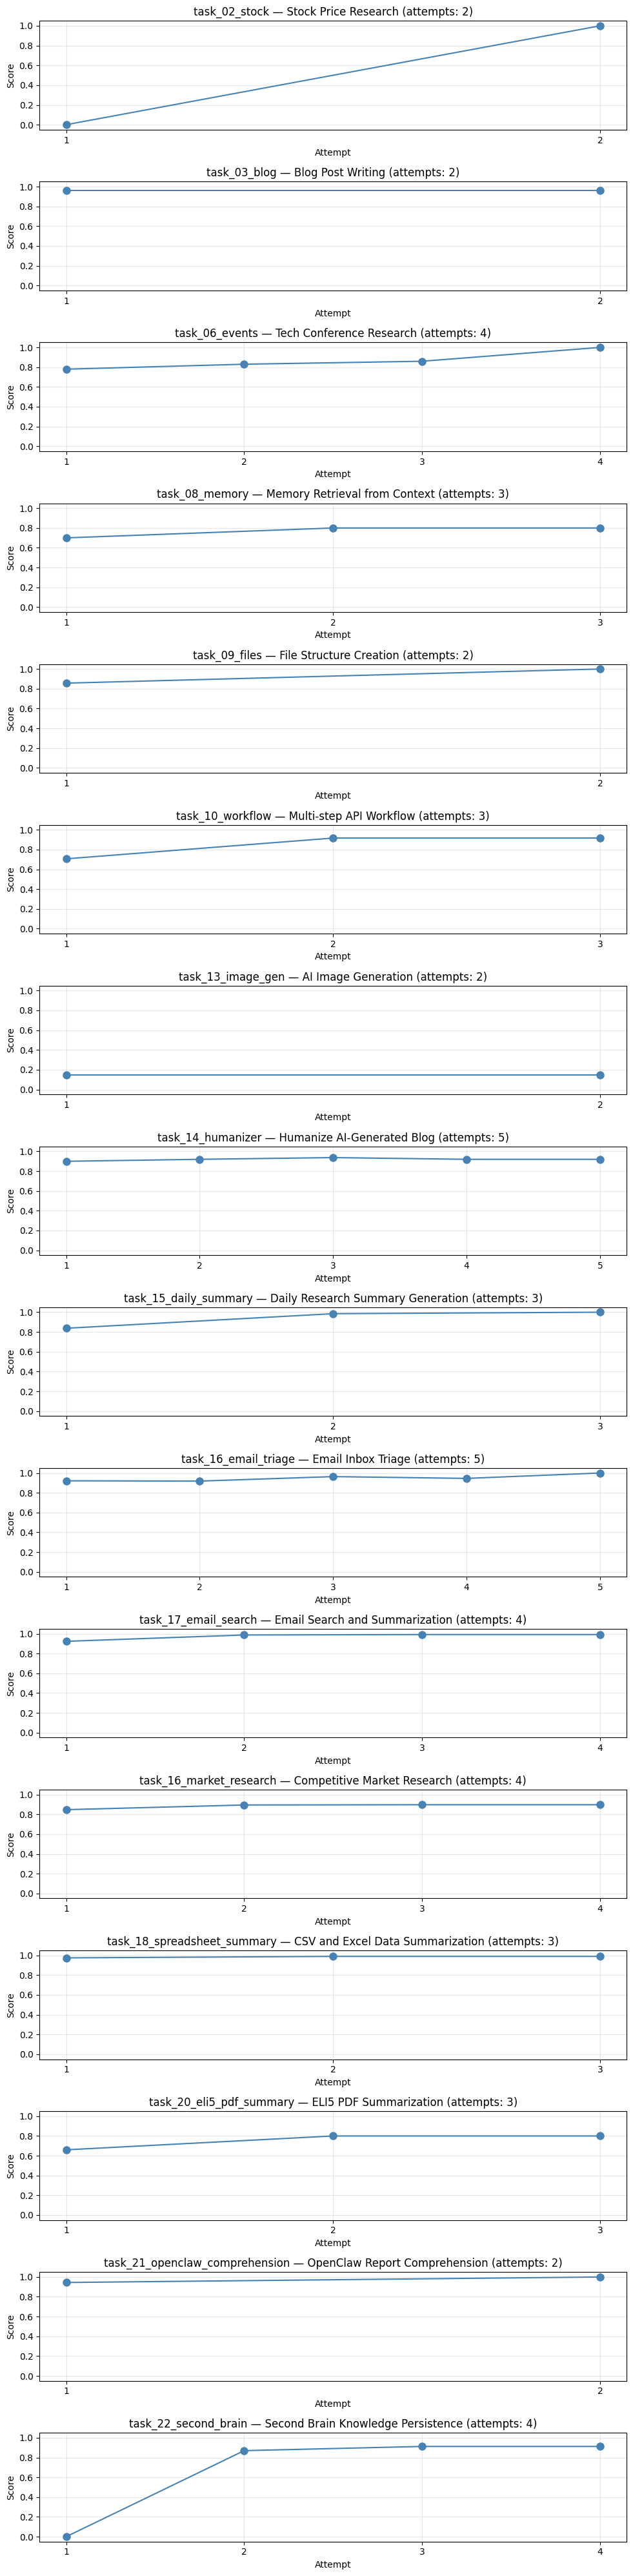

In [7]:
# 汇总每个 task 的每一轮 attempt：得分、耗时、状态
attempt_rows = []
for r in rows:
    for a in r["attempts"]:
        attempt_rows.append({
            "task_id": r["task_id"],
            "name": r["name"],
            "attempt": a["attempt"],
            "score": a["score"],
            "max_score": a["max_score"],
            "execution_time": a["execution_time"],
            "status": a["status"],
        })

# 仅多 attempt 的 task：画 尝试序号 vs 得分
multi = [r for r in rows if r["attempt_count"] > 1]
if not multi:
    print("没有多轮 attempt 的 task。")
else:
    fig, axes = plt.subplots(len(multi), 1, figsize=(10, 2.5 * len(multi)), sharex=False)
    if len(multi) == 1:
        axes = [axes]
    for i, r in enumerate(multi):
        ax = axes[i]
        atts = r["attempts"]
        nums = [x["attempt"] for x in atts]
        scs = [x["score"] for x in atts]
        ax.plot(nums, scs, "o-", color="steelblue", markersize=8)
        ax.set_ylabel("Score")
        ax.set_xlabel("Attempt")
        ax.set_title(f"{r['task_id']} — {r['name']} (attempts: {r['attempt_count']})")
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(nums)
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# 表：每个 task 的每一轮 attempt（得分 + 耗时）
if attempt_rows:
    try:
        import pandas as pd
        df = pd.DataFrame(attempt_rows)
        df["score_pct"] = (df["score"] / df["max_score"].replace(0, 1) * 100).round(1)
        display(df[["task_id", "attempt", "score", "max_score", "score_pct", "execution_time", "status"]])
    except Exception:
        for row in attempt_rows[:20]:
            print(row)
        if len(attempt_rows) > 20:
            print("...", len(attempt_rows) - 20, "more rows")

In [8]:
# 本 run 效率汇总（来自 JSON 顶层 efficiency）
for k, v in (efficiency or {}).items():
    if k != "per_task":
        print(f"  {k}: {v}")

  total_tokens: 9699979
  total_input_tokens: 5573629
  total_output_tokens: 90600
  total_cost_usd: 0.0
  total_requests: 337
  total_execution_time_seconds: 1268.46
  tasks_with_usage_data: 23
  tokens_per_task: 421738.2
  cost_per_task_usd: 0.0
  score_per_1k_tokens: 0.0022
  score_per_dollar: None
